In [34]:
import pandas as pd
import numpy as np
from pathlib import Path

import umap
import hdbscan
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import PCA
from clustering.hdbscan_optimize import optimize_umap_hdbscan_auto
from visualization.samples_plot import show_clustering_samples
from visualization.plot import plot_clustering_on_umap
from hdbscan.validity import validity_index


PROJECT_ROOT = Path.cwd().resolve().parent
EMBEDDING_DIR = PROJECT_ROOT / "data" / "glomeruli" / "embeddings"

EMBEDDING_NAME = "densenet_crops_embeddings"

embedding: np.ndarray = np.load(EMBEDDING_DIR / f"{EMBEDDING_NAME}.npy")
csv = pd.read_csv(EMBEDDING_DIR / f"{EMBEDDING_NAME}.csv")

n_samples = embedding.shape[0]

In [35]:
embedding_l2 = Normalizer(norm="l2").fit_transform(embedding)

pca_95 = PCA(n_components=0.95)
pca_95_embedding = pca_95.fit_transform(embedding_l2)

In [36]:
best = optimize_umap_hdbscan_auto(
    pca_95_embedding,
    n_runs=20,

    min_dist=0.1,
    min_clusters=2,
    max_clusters=10,
    max_noise=0.33,

    min_valid_run_ratio=0.80,
    min_mean_ari=0.50,
    min_mean_dbcv=0.4,

    dbcv_weight=0.50,
    valid_run_ratio_weight=0.30,
    noise_weight=0.20,

    cluster_selection_method="eom",
    max_auto_param_combinations=100,
)

best_params = best["best_params"]
best_n_components = best["best_n_components"]

if best_n_components is None:
    raise ValueError("No suitable number of components found for UMAP.")

print(best_params)

{'umap': {'n_neighbors': 34, 'min_dist': 0.1, 'metric': 'cosine', 'n_components': 40}, 'hdbscan': {'metric': 'euclidean', 'min_cluster_size': 14, 'min_samples': 10, 'cluster_selection_method': 'eom'}, 'constraints': {'min_clusters': 2, 'max_clusters': 10, 'max_noise': 0.33, 'min_valid_run_ratio': 0.8, 'min_mean_ari': 0.5, 'min_mean_dbcv': 0.4}, 'selection': {'metric': 'combined_score', 'dbcv_weight': 0.5, 'valid_run_ratio_weight': 0.3, 'noise_weight': 0.2, 'single_cluster_dbcv_for_score': 0.0}}


In [37]:
umap_params = best_params["umap"]

umap_embedding = umap.UMAP(
    n_neighbors=umap_params["n_neighbors"],
    min_dist=umap_params["min_dist"],
    n_components=umap_params["n_components"],
    metric=umap_params["metric"],
).fit_transform(pca_95_embedding)

In [38]:
hdbscan_params = best_params["hdbscan"]

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=hdbscan_params["min_cluster_size"],
    min_samples=hdbscan_params["min_samples"],
    metric=hdbscan_params["metric"],
    cluster_selection_method=hdbscan_params["cluster_selection_method"]
)

labels = clusterer.fit_predict(umap_embedding)

probabilities = clusterer.probabilities_    # How much a points belong to the assigned cluster
outlier_scores = clusterer.outlier_scores_  # How much a point is anomalous compared to the rest of the data

In [39]:
cluster_ids = sorted(label for label in np.unique(labels) if label != -1)

if len(cluster_ids) >= 2:
    dbcv_global, dbcv_per_cluster = validity_index(
        np.asarray(umap_embedding, dtype=np.float64),
        labels,
        metric="euclidean",
        per_cluster_scores=True,
    )
else:
    dbcv_global = np.nan
    dbcv_per_cluster = [np.nan for _ in cluster_ids]

dbcv_by_cluster = dict(zip(cluster_ids, dbcv_per_cluster))

cluster_dbcv_summary = pd.DataFrame(
    [
        {
            "cluster": int(cluster_id),
            "size": int(np.sum(labels == cluster_id)),
            "dbcv": float(dbcv_by_cluster[cluster_id]),
        }
        for cluster_id in cluster_ids
    ]
)

if np.any(labels == -1):
    cluster_dbcv_summary = pd.concat(
        [
            cluster_dbcv_summary,
            pd.DataFrame([
                {
                    "cluster": -1,
                    "size": int(np.sum(labels == -1)),
                    "dbcv": np.nan,
                }
            ]),
        ],
        ignore_index=True,
    )

print(f"DBCV globale: {dbcv_global:.4f}")
display(cluster_dbcv_summary.sort_values("cluster").reset_index(drop=True))

DBCV globale: 0.4469


,cluster,size,dbcv
0,-1,87,NaN
1,0,370,0.534881
2,1,30,0.798718
3,2,134,0.398455
4,3,56,0.487432


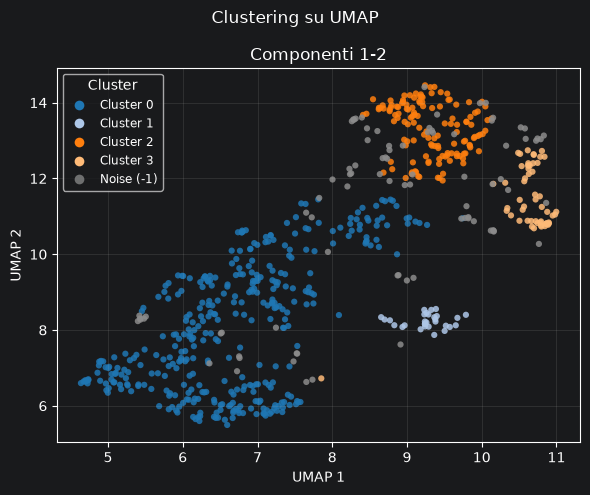

(<Figure size 600x500 with 1 Axes>,
 (<Axes: title={'center': 'Componenti 1-2'}, xlabel='UMAP 1', ylabel='UMAP 2'>,))

In [40]:
plot_clustering_on_umap(
    pca_95_embedding,
    labels,
    min_dist=0.05,
    n_neighbors=umap_params["n_neighbors"],
)

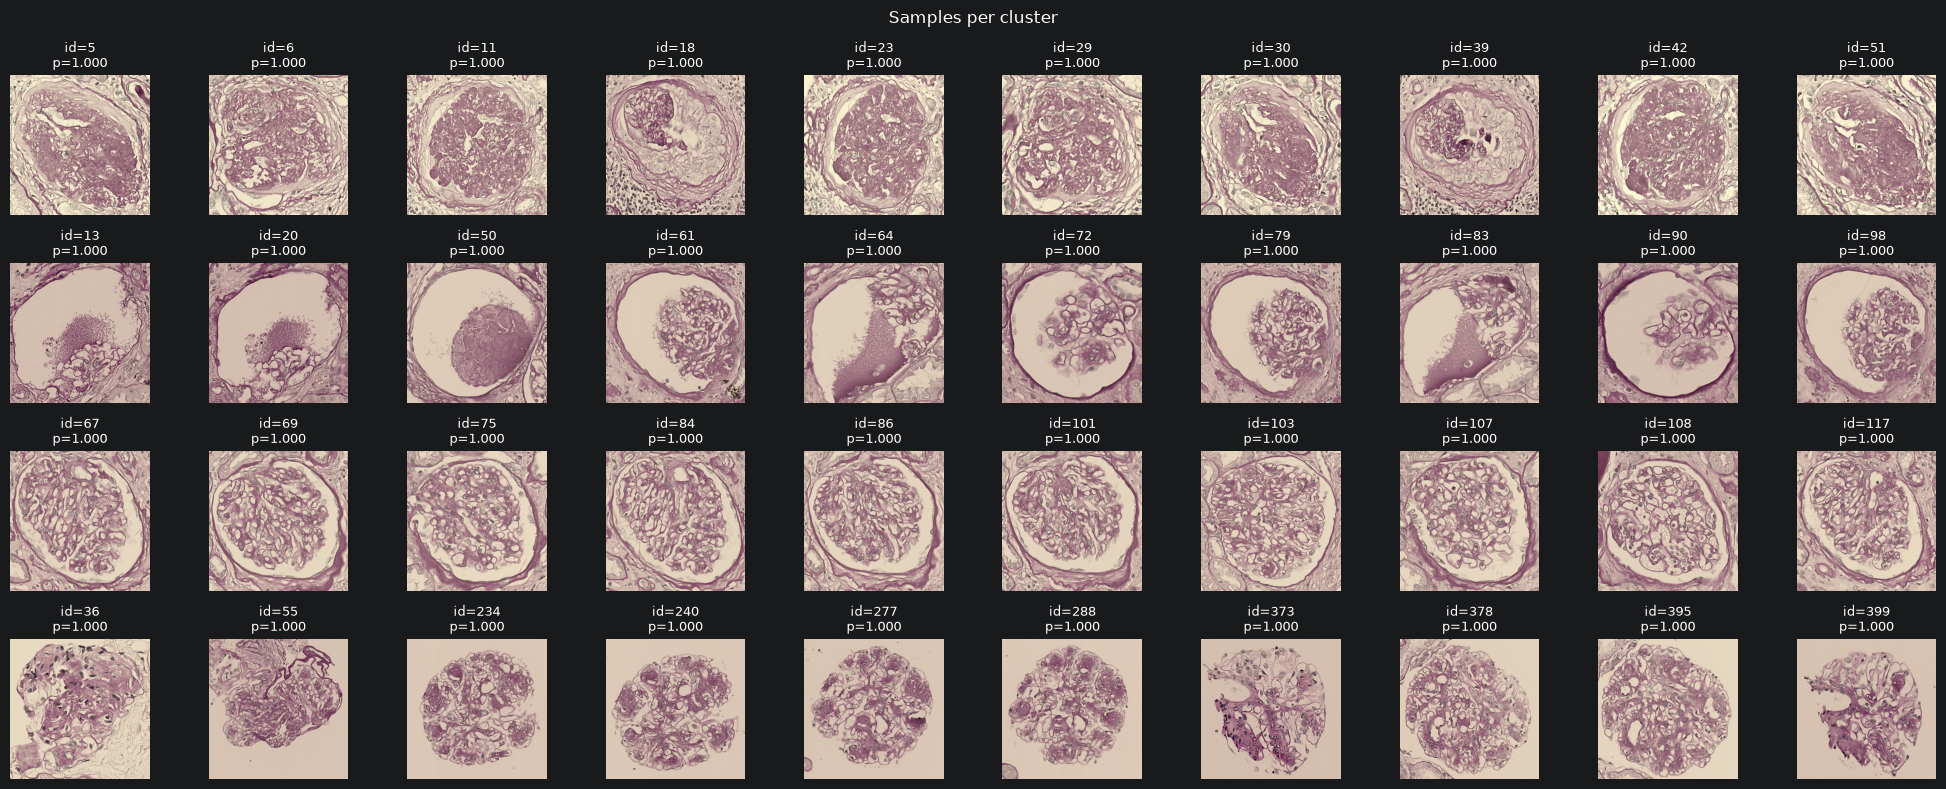

In [41]:
image_paths = csv["image_path"].tolist()

sample_figure, sample_axes = show_clustering_samples(
    labels=labels,
    probabilities=clusterer.probabilities_,
    image_paths=image_paths,
    x=10,
    base_dir=PROJECT_ROOT,
    image_size=2.0,
)

In [42]:
cols = [
    "n_components",
    "successful_runs",
    "valid_runs",
    "valid_run_ratio",
    "mean_dbcv",
    "mean_ari",
    "mean_dbcv_all",
    "mean_ari_all",
    "mean_n_clusters_all",
    "mean_noise_ratio_all",
    "valid_for_selection",
]

print(best["results"][cols].sort_values("n_components"))

print(
    best["run_details"]
    .groupby(["n_components", "constraint_reason"])
    .size()
    .unstack(fill_value=0)
)

    n_components  successful_runs  valid_runs  valid_run_ratio  mean_dbcv  \
21            10               20          19             0.95   0.401378   
47            10               20          20             1.00   0.347828   
46            10               20          20             1.00   0.334184   
56            10               20          20             1.00   0.320642   
57            10               20          20             1.00   0.303819   
..           ...              ...         ...              ...        ...   
78            50               20          19             0.95   0.328024   
69            50               20          20             1.00   0.316122   
72            50               20          20             1.00   0.281539   
65            50               20          20             1.00   0.295525   
66            50               20          20             1.00   0.313323   

    mean_ari  mean_dbcv_all  mean_ari_all  mean_n_clusters_all  \
21  0.466